In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Preprocessing:

In [2]:
data = pd.read_csv('anime.csv')

### Data Preprocessing :

In [59]:
data.head(10)

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1.0,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24.0,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.16,151266
5,32935,Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...,"Comedy, Drama, School, Shounen, Sports",TV,10.0,9.15,93351
6,11061,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",TV,148.0,9.13,425855
7,820,Ginga Eiyuu Densetsu,"Drama, Military, Sci-Fi, Space",OVA,110.0,9.11,80679
8,15335,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,"Action, Comedy, Historical, Parody, Samurai, S...",Movie,1.0,9.10,72534
9,15417,Gintama&#039;: Enchousen,"Action, Comedy, Historical, Parody, Samurai, S...",TV,13.0,9.11,81109


In [3]:
data.shape

(12294, 7)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [5]:
data.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [6]:
data['episodes'] = data['episodes'].replace('Unknown',np.nan)

In [7]:
data.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes    340
rating      230
members       0
dtype: int64

In [8]:
data['episodes'] = pd.to_numeric(data['episodes'])

In [9]:
data['genre'] = data['genre'].fillna('')

data['type'] = data['type'].fillna(data['type'].mode()[0])

data['rating'] = data['rating'].fillna(data['rating'].mean())

data['episodes'] = data['episodes'].fillna(data['episodes'].median())

In [10]:
data.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

### Visualization :

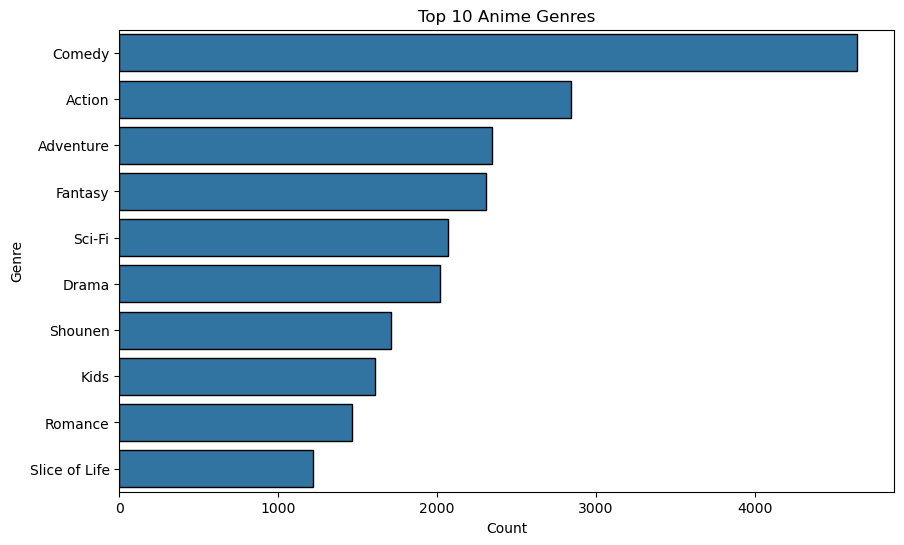

In [52]:
# Split genres and count them
genres = data['genre'].str.split(',')

all_genres = []

for genre_list in genres:
    if isinstance(genre_list, list):
        for genre in genre_list:
            all_genres.append(genre.strip())

# Count top genres
genre_count = pd.Series(all_genres).value_counts().head(10)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=genre_count.values, y=genre_count.index,edgecolor = 'k')

plt.title('Top 10 Anime Genres')
plt.xlabel('Count')
plt.ylabel('Genre')

plt.show()

#### - Comedy is the most popular genre in the dataset. Action and Adventure are also highly common, showing that viewers enjoy exciting and entertaining anime.

#### - Fantasy, Sci‑Fi, Drama, and Romance genres are also popular among audiences. Slice of Life has fewer anime compared to other genres.

#### - Overall, the dataset mainly contains entertainment-focused genres like Comedy, Action, and Adventure.

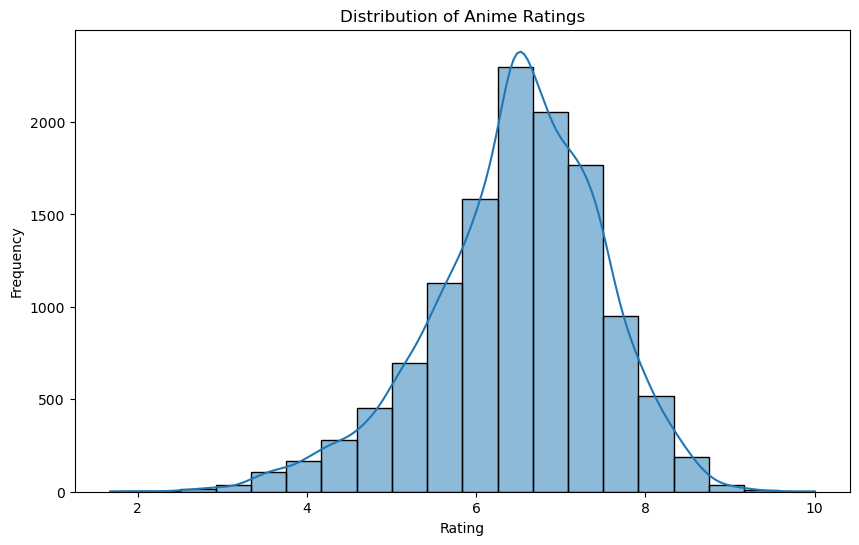

In [53]:
plt.figure(figsize=(10,6))

sns.histplot(data['rating'], bins=20, kde=True)

plt.title('Distribution of Anime Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.show()

#### - Most anime ratings are concentrated between 6 and 8, indicating that the majority of anime are moderately to highly rated by users.
#### - Very few anime have extremely low or extremely high ratings.

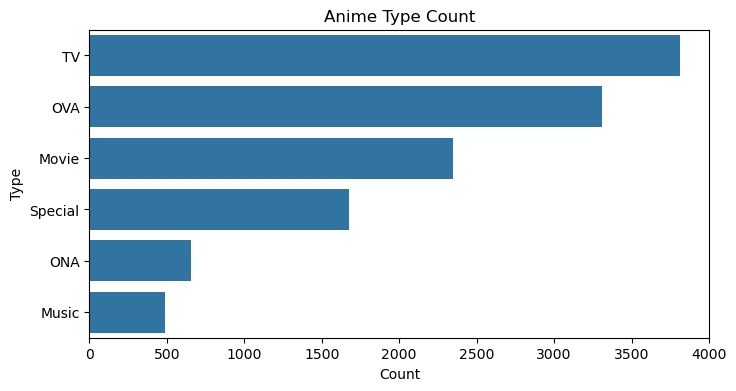

In [55]:
plt.figure(figsize=(8,4))

sns.countplot(y=data['type'],order=data['type'].value_counts().index)

plt.title('Anime Type Count')
plt.xlabel('Count')
plt.ylabel('Type')

plt.show()

#### - TV series are the most common type of anime in the dataset, followed by OVA and Movies.
#### - ONA and Music categories have the lowest counts, indicating they are less frequently produced compared to TV anime.

### Feature Extraction :

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [60]:
data['combined_features'] = ( data['genre'].fillna('') + ' ' + data['type'].fillna('') + ' ' + data['rating'].astype(str))

In [61]:
tfidf = TfidfVectorizer(stop_words='english')
genre_matrix = tfidf.fit_transform(data['combined_features'])

### Cosine Similarity :

In [62]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(genre_matrix)

In [63]:
cosine_sim

array([[1.        , 0.08525306, 0.        , ..., 0.        , 0.        ,
        0.11121693],
       [0.08525306, 1.        , 0.16633031, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.16633031, 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 0.3272428 ,
        0.23089043],
       [0.        , 0.        , 0.        , ..., 0.3272428 , 1.        ,
        0.21898861],
       [0.11121693, 0.        , 0.        , ..., 0.23089043, 0.21898861,
        1.        ]])

### Recommendation Function :

In [64]:
indices = pd.Series(data.index, index=data['name']).drop_duplicates()

In [65]:
def recommend_anime(title):

    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:]

    anime_indices = [i[0] for i in sim_scores]
    
    recommended = []

    for i in anime_indices:
        anime_name = data['name'].iloc[i]

        # Skip same anime
        if anime_name.lower() != title.lower():

            # Avoid duplicates
            if anime_name not in recommended:
                recommended.append(anime_name)

        # Return only 5 anime
        if len(recommended) == 5:
            break

    return recommended

In [69]:
recommend_anime("Naruto")

['Iron Virgin Jun',
 'Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono',
 'Dragon Ball Super',
 'Ikkitousen: Extravaganza Epoch',
 'Tenjou Tenge']

#### It shows the recommendation based on genre, type, rating similarity

### Interview Questions:

#### 1. Can you explain the difference between user-based and item-based collaborative filtering?
#### -> 1.user-based Collaborative Filtering: 
##### I. Recommends items based on similar users.
##### II. Finds users with similar preferences.
##### III. Example: Users who liked Naruto also liked One Piece.
##### IV. Similarity is calculated between users.
##### V. Less scalable for large datasets.

#### 2. Item-Based Collaborative Filtering : 
##### I. Recommends items based on similar Items.
##### II. Finds items that are commonly liked together
##### III. Example: Naruto is similar to Bleach
##### IV. Similarity is calculated between items
##### V. More efficient and widely used


#### 2. What is collaborative filtering, and how does it work?

#### -> Collaborative filtering is a recommendation technique used to suggest items based on user behavior, preferences, and interactions. 
#### It works by identifying similarities between users or items and recommending products, movies, or anime accordingly.

#### There are two main types:

##### 1.User-Based Collaborative Filtering
##### 2.Item-Based Collaborative Filtering

#### For example, if many users who watched Naruto also watched One Piece, the system may recommend One Piece to a Naruto viewer.

#### Collaborative filtering is commonly used in:

##### 1.Netflix
##### 2.Amazon
##### 3.Spotify
##### 4.YouTube recommendation systems